# Time Series Analysis in Medicine and Biology
## Practical Course — University of Tübingen · PfeiferLab

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ShamsaraE/time-series-medicine-biology/blob/main/teaching/04_cgm_hourly_cross_analysis.ipynb)

---

# Notebook 04 — Hourly Cross-Analysis of Continuous Glucose & Heart Rate

**In this notebook you will:**
1. Resample dense **continuous glucose monitoring (CGM)** data to an **hourly** resolution.
2. Standardise two signals (glucose and heart rate) and compute their **cross-correlation** with approximate significance bounds.
3. Remove the **mean daily profile** (the behavioural routine) from both signals and see how the coupling changes.
4. Compare **cosine similarity** before and after, and compute a **partial cross-correlation via prewhitening** (AR residuals).

**Dataset:** `CGMacros-001` — one subject's minute-level glucose, heart rate, activity and meal
records, loaded from this repository's `data/` folder. Publicly available at
https://physionet.org/content/cgmacros/1.0.0/

**Why this matters:** two physiological signals can look correlated simply because both follow
the same daily routine (wake, eat, sleep). Removing the shared daily profile and prewhitening
are the standard ways to ask whether there is coupling *beyond* that common schedule.

## 1. Imports

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from numpy.linalg import norm
from statsmodels.tsa.arima.model import ARIMA

plt.rcParams["figure.figsize"] = (10, 4)



## 2. Load Data



In [2]:

DATA_PATH = "https://raw.githubusercontent.com/ShamsaraE/time-series-medicine-biology/main/data/CGMacros-001.csv"

df = pd.read_csv(DATA_PATH)
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp").set_index("Timestamp")

df.head()


,Unnamed: 0,Libre GL,Dexcom GL,HR,Calories (Activity),METs,Meal Type,Calories,Carbs,Protein,Fat,Fiber,Amount Consumed,Image path
Timestamp,,,,,,,,,,,,,,
2020-05-01 10:30:00,0,84.000000,NaN,56.0,1.0484,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-05-01 10:31:00,1,84.133333,NaN,56.0,1.0484,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-05-01 10:32:00,2,84.266667,NaN,57.0,1.0484,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-05-01 10:33:00,3,84.400000,NaN,54.0,1.0484,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-05-01 10:34:00,4,84.533333,NaN,55.0,1.0484,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



### 2.1 Column Guide (data is publicly available at https://physionet.org/content/cgmacros/1.0.0/)

The dataset typically includes (names may vary slightly):

- **Libre GL**: interstitial glucose from Libre sensor (mg/dL)
- **Dexcom GL**: glucose from Dexcom sensor (mg/dL) (often missing if not used)
- **HR**: heart rate (beats per minute)
- **Calories (Activity)**: estimated calories burned from activity
- **METs**: metabolic equivalents (activity intensity proxy)
- **Meal Type**: categorical annotation of meal (if provided)
- **Calories**: meal calories (if logged)
- **Carbs**: carbohydrate grams (if logged)
- **Unnamed: 0**: usually a row index saved in the CSV (not meaningful as a variable)

Physiological intuition:
- **Glucose** responds to meals + insulin dynamics and has short-term inertia.
- **HR** reflects activity, stress, and autonomic response; it also has strong daily routine structure.



## 3. Basic Cleaning 

We often drop the accidental CSV index column (`Unnamed: 0`) if present.


In [3]:

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df.info()


<class 'pandas.DataFrame'>
DatetimeIndex: 14730 entries, 2020-05-01 10:30:00 to 2020-05-11 15:59:00
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Libre GL             14730 non-null  float64
 1   Dexcom GL            14265 non-null  float64
 2   HR                   14618 non-null  float64
 3   Calories (Activity)  14730 non-null  float64
 4   METs                 14729 non-null  float64
 5   Meal Type            43 non-null     str    
 6   Calories             43 non-null     float64
 7   Carbs                43 non-null     float64
 8   Protein              43 non-null     float64
 9   Fat                  43 non-null     float64
 10  Fiber                42 non-null     float64
 11  Amount Consumed      43 non-null     float64
 12  Image path           81 non-null     str    
dtypes: float64(11), str(2)
memory usage: 1.6 MB



## 4. Resample to Hourly Resolution

We aggregate minute-level readings to **hourly means**.

Why?
- reduces high-frequency sensor noise
- makes lag interpretation natural (lag=1 → 1 hour)


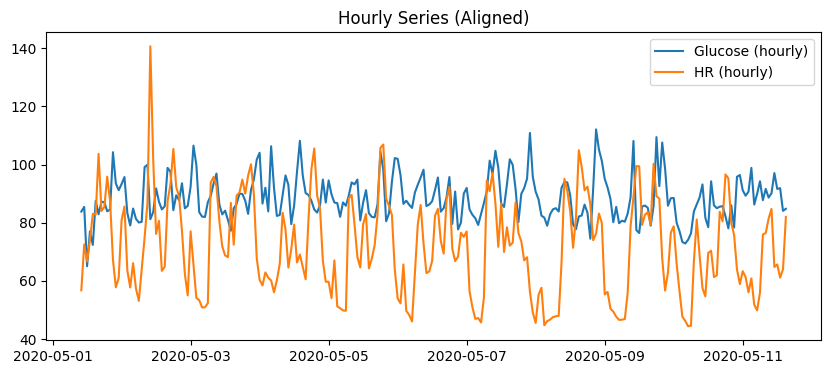

246

In [4]:
# Average only the numeric columns; text columns (Meal Type, Image path) can't be averaged
df_hourly = df.select_dtypes("number").resample("1h").mean()

# Choose two variables for cross-analysis (default: glucose & HR)
glucose = df_hourly["Libre GL"].astype(float)
hr = df_hourly["HR"].astype(float) 


# Keep only aligned (non-missing) pairs
data = pd.concat([glucose, hr], axis=1).dropna()
glucose = data["Libre GL"]
hr = data["HR"]

plt.figure()
plt.plot(glucose, label="Glucose (hourly)")
plt.plot(hr, label="HR (hourly)")
plt.title("Hourly Series (Aligned)")
plt.legend()
plt.show()

len(data)



## 5. Standardize Before Similarity / Correlation

We use z-score standardization:

$
Z_t = \frac{X_t - \mu}{\sigma}
$

Why?
- cross-correlation and cosine similarity are easier to compare across variables
- removes scale effects (mg/dL vs bpm)


In [5]:

glucose_z = (glucose - glucose.mean()) / glucose.std()
hr_z = (hr - hr.mean()) / hr.std()



## 6. Cross-Correlation with Approximate Significance Bounds

We compute, for each lag $\ell $:

$
\mathrm{CCF}(\ell) = Corr(G_t, H_{t-\ell})
$

Interpretation of lags (given this definition):
- **Positive lag** $ \ell > 0 $: HR leads glucose (HR earlier than glucose)
- **Negative lag** $ \ell < 0 $: glucose leads HR

### Approximate significance bounds

A common heuristic for white noise is:

$
\pm \frac{2}{\sqrt{N}}
$



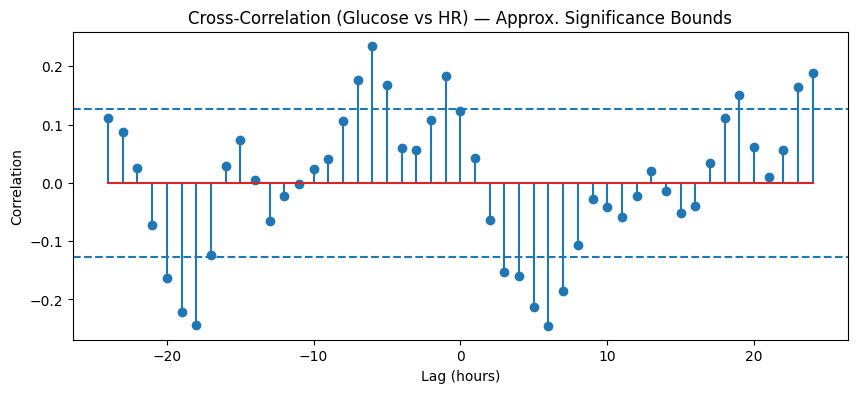

N = 246   threshold = 0.12751534261266764
Largest |corr| at lag = 6  value = 0.24509003413855027


In [6]:

def cross_corr(x: np.ndarray, y: np.ndarray, max_lag: int = 24):
    """Compute Corr(x_t, y_{t-lag}) for lags in [-max_lag, +max_lag]."""
    lags = np.arange(-max_lag, max_lag + 1)
    values = []
    for lag in lags:
        if lag < 0:
            # correlate x_{t} with y_{t-(-lag)} = y_{t+lag}: x[-lag:] aligns with y[:lag]
            c = np.corrcoef(x[-lag:], y[:lag])[0, 1]
        elif lag > 0:
            c = np.corrcoef(x[:-lag], y[lag:])[0, 1]
        else:
            c = np.corrcoef(x, y)[0, 1]
        values.append(c)
    return lags, np.array(values)

max_lag = 24
lags, ccs = cross_corr(glucose_z.values, hr_z.values, max_lag=max_lag)

N = len(glucose_z)
threshold = 2 / np.sqrt(N)

plt.figure()
plt.stem(lags, ccs)
plt.axhline(threshold, linestyle="--")
plt.axhline(-threshold, linestyle="--")
plt.title("Cross-Correlation (Glucose vs HR) — Approx. Significance Bounds")
plt.xlabel("Lag (hours)")
plt.ylabel("Correlation")
plt.show()

print("N =", N, "  threshold =", threshold)
print("Largest |corr| at lag =", lags[np.argmax(np.abs(ccs))], " value =", np.max(np.abs(ccs)))



### Interpretation (Raw CCF)

From the printed output:

- $N = 246$ hourly observations (aligned glucose–HR pairs)
- Approx. significance threshold: $\pm 2/\sqrt{N} \approx \pm 0.128$
- Largest absolute cross-correlation occurs at **lag = +6 hours** with value **≈ 0.245**

**Lag interpretation (our convention):**
$\mathrm{CCF}(\ell) = Corr(G_t, H_{t-\ell})$

- **$\ell>0$** means **HR leads glucose** (HR changes occur earlier)
- **$\ell<0$** means **glucose leads HR**

So the peak at **$\ell=+6$** suggests that **HR fluctuations tend to precede glucose deviations by ~6 hours** *in the raw signals*.

**Key caution:** this “raw” association can be dominated by shared daily routine (sleep/wake, meals, activity timing). That’s why we remove the mean daily profile next.



## 8. Remove Mean Daily Profile (Behavioral Routine)



Both glucose and HR often show **time-of-day structure** driven by routine:
- meals often occur at similar times
- sleep/wake schedules repeat
- activity patterns repeat

If we compute cross-correlation on raw signals, we may be detecting **shared daily routine**
rather than a direct physiological coupling.

We remove the mean profile by hour-of-day:

$
X^{adj}_t = X_t - \overline{X}_{hour(t)}
$

We apply this to **both glucose and HR**.


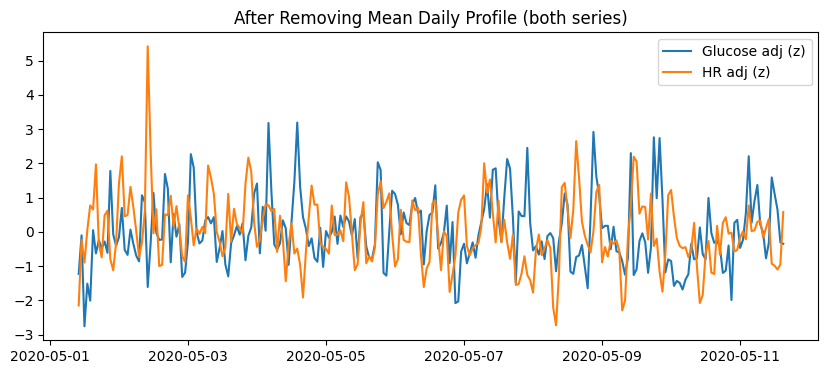

246

In [7]:

# Build hour-of-day labels
hour_of_day = df_hourly.index.hour

# Mean daily profiles (by hour) for glucose and HR
mean_glucose_hour = df_hourly.groupby(hour_of_day)["Libre GL"].mean()
mean_hr_hour = df_hourly.groupby(hour_of_day)["HR"].mean()

# Adjust (demean by hour-of-day)
glucose_adj = df_hourly["Libre GL"] - hour_of_day.map(mean_glucose_hour)
hr_adj = df_hourly["HR"] - hour_of_day.map(mean_hr_hour)

# Keep aligned pairs
data_adj = pd.concat([glucose_adj, hr_adj], axis=1).dropna()
glucose_adj = data_adj.iloc[:, 0].astype(float)
hr_adj = data_adj.iloc[:, 1].astype(float)

# Standardize adjusted series
glucose_adj_z = (glucose_adj - glucose_adj.mean()) / glucose_adj.std()
hr_adj_z = (hr_adj - hr_adj.mean()) / hr_adj.std()

plt.figure()
plt.plot(glucose_adj_z, label="Glucose adj (z)")
plt.plot(hr_adj_z, label="HR adj (z)")
plt.title("After Removing Mean Daily Profile (both series)")
plt.legend()
plt.show()

len(data_adj)


## 9. Cross-Correlation After Daily Profile Removal

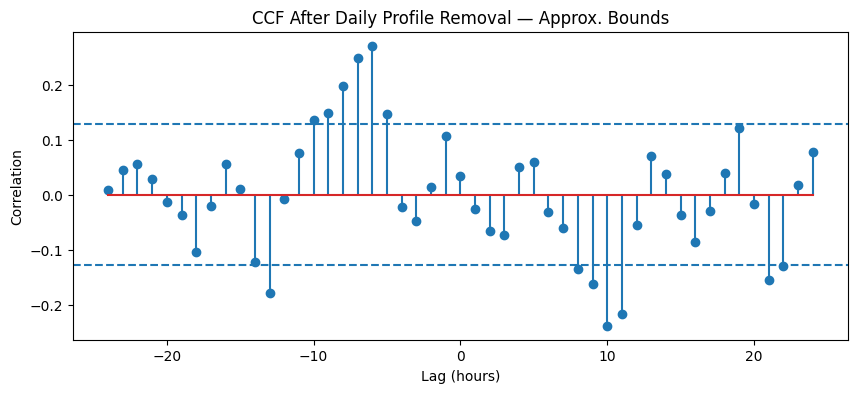

N2 = 246   threshold2 = 0.12751534261266764
Largest |corr| at lag = -6  value = 0.270758386099386


In [8]:

lags2, ccs2 = cross_corr(glucose_adj_z.values, hr_adj_z.values, max_lag=max_lag)

N2 = len(glucose_adj_z)
threshold2 = 2 / np.sqrt(N2)

plt.figure()
plt.stem(lags2, ccs2)
plt.axhline(threshold2, linestyle="--")
plt.axhline(-threshold2, linestyle="--")
plt.title("CCF After Daily Profile Removal — Approx. Bounds")
plt.xlabel("Lag (hours)")
plt.ylabel("Correlation")
plt.show()

print("N2 =", N2, "  threshold2 =", threshold2)
print("Largest |corr| at lag =", lags[np.argmax(np.abs(ccs2))], " value =", np.max(np.abs(ccs2)))



## 7. Cosine Similarity (Global Shape Similarity)

Cosine similarity compares the **overall direction/shape** of two standardized vectors:

$
\cos(\theta) = \frac{x \cdot y}{\|x\| \, \|y\|}
$

- close to **1**: aligned dynamics
- close to **0**: largely unrelated
- close to **-1**: opposing dynamics


In [9]:

cos_sim_raw = float(np.dot(glucose_z.values, hr_z.values) / (norm(glucose_z.values) * norm(hr_z.values)))
cos_sim_raw


0.1231669463962178


### Interpretation (Cosine similarity — raw)

The raw cosine similarity is:

- **cosine ≈ 0.123**

This is a **small positive** global alignment. It indicates that, overall, glucose and HR are *slightly* aligned in direction, but not strongly.

**Why cosine is useful here:** it summarizes *overall shape alignment* across the whole window, while the CCF shows *lag-specific* alignment.


## 10. Cosine Similarity After Daily Profile Removal

In [10]:

cos_sim_adj = float(np.dot(glucose_adj_z.values, hr_adj_z.values) / (norm(glucose_adj_z.values) * norm(hr_adj_z.values)))
cos_sim_adj


0.03329968486589573


### Interpretation (Cosine similarity — after daily-profile removal)

The cosine similarity after daily-profile removal is:

- **cosine ≈ 0.033**

This is **very close to zero**, meaning that once we remove the shared daily routine, the two series have almost **no global shape similarity** over the entire window.

This supports the interpretation that the raw similarity was largely driven by routine (e.g., meals, activity schedules).



## 11. Partial Cross-Correlation via Prewhitening 

### Why "partial" cross-correlation?

Raw cross-correlation can be inflated because:
- glucose is autocorrelated (physiological inertia)
- HR is autocorrelated (activity inertia)

To isolate **direct coupling**, we **prewhiten** each series:
1. Fit a small AR model to glucose and take residuals (innovation process)
2. Fit a small AR model to HR and take residuals
3. Compute cross-correlation between residuals

Residual-residual CCF is closer to a **partial** relationship because the internal memory
of each series has been removed.

We keep AR order small (often 1–3) for teaching clarity.


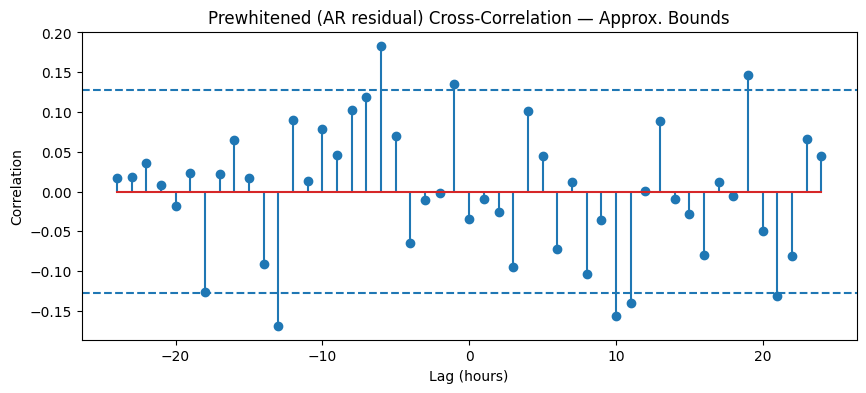

N3 = 246   threshold3 = 0.12751534261266764
Largest |corr| at lag = -6  value = 0.18331815524574574


In [11]:

def prewhiten_residuals(series: pd.Series, ar_order: int = 2) -> pd.Series:
    """Fit ARIMA(p,0,0) and return residuals aligned to index."""
    # ARIMA will drop initial values internally; we drop NaNs first for stability
    s = series.dropna()
    fit = ARIMA(s, order=(ar_order, 0, 0)).fit()
    r = fit.resid
    return r

# Choose small AR orders (adjust if needed after checking ACF/PACF)
p_g = 2
p_h = 2

g_resid = prewhiten_residuals(glucose_adj_z, ar_order=p_g)
h_resid = prewhiten_residuals(hr_adj_z, ar_order=p_h)

# Align residuals
resid_df = pd.concat([g_resid, h_resid], axis=1).dropna()
g_resid = resid_df.iloc[:, 0]
h_resid = resid_df.iloc[:, 1]

lags3, ccs3 = cross_corr(g_resid.values, h_resid.values, max_lag=max_lag)

N3 = len(g_resid)
threshold3 = 2 / np.sqrt(N3)

plt.figure()
plt.stem(lags3, ccs3)
plt.axhline(threshold3, linestyle="--")
plt.axhline(-threshold3, linestyle="--")
plt.title("Prewhitened (AR residual) Cross-Correlation — Approx. Bounds")
plt.xlabel("Lag (hours)")
plt.ylabel("Correlation")
plt.show()

print("N3 =", N3, "  threshold3 =", threshold3)
print("Largest |corr| at lag =", lags[np.argmax(np.abs(ccs3))], " value =", np.max(np.abs(ccs3)))


## Key takeaways

- Aligning signals to a common **hourly grid** is the first step before any cross-signal analysis.
- **Raw cross-correlation** between two physiological signals is often inflated by their shared **daily routine**; removing the mean daily profile isolates the genuine coupling.
- **Prewhitening** (removing each series' own autocorrelation via an AR fit) gives a cleaner picture of lead/lag relationships than raw cross-correlation.

**Try it yourself:**
1. Swap heart rate for `METs` or `Calories (Activity)` as the second signal — is the coupling stronger?
2. Change the resampling to 30-minute resolution. Does the strongest lag move?
3. Increase the AR order in the prewhitening step and see how the partial cross-correlation changes.